In [37]:
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

from roar import ALL_VEHICLES, MEASUREMENTS, ROOT_DIR, VEHICLE_COLORS

sns.set_style("whitegrid")
sns.set_palette("husl")

In [38]:
# FILE_PATH = "measure_logo_results.csv"
FILE_PATH = ROOT_DIR / "results" / "vehicle_logo_results.csv"

In [39]:
df = pl.read_csv(FILE_PATH)

if FILE_PATH.stem.startswith("measure_logo"):
    LOGO_GROUP = "measure"
    idx2name = {idx: measure for idx, measure in enumerate(MEASUREMENTS)}
    SPLIT_ORDER = MEASUREMENTS
    SPLIT_PALETTE = None
elif FILE_PATH.stem.startswith("vehicle_logo"):
    LOGO_GROUP = "vehicle"
    idx2name = {idx: vehicle for idx, vehicle in enumerate(ALL_VEHICLES)}
    SPLIT_ORDER = ALL_VEHICLES
    SPLIT_PALETTE = VEHICLE_COLORS

In [40]:
df.sort("mean_test_weighted_f1", descending=True).select(
    ["mean_test_weighted_f1", "model", "param_feature_selector__feature_set"]
).head(10)

mean_test_weighted_f1,model,param_feature_selector__feature_set
f64,str,str
0.884856,"""tabpfn_emb_rf""","""cleaned"""
0.884321,"""tabpfn_emb_log_reg""","""cleaned"""
0.880921,"""tabpfn_emb_log_reg""","""cleaned"""
0.879233,"""tabpfn_emb_log_reg""","""cleaned"""
0.875936,"""tabpfn_emb_log_reg""","""cleaned"""
0.874041,"""tabpfn_emb_log_reg""","""cleaned"""
0.869037,"""tabpfn_emb_log_reg""","""cleaned"""
0.86818,"""tabpfn_emb_log_reg""","""cleaned"""
0.867221,"""tabpfn_emb_log_reg""","""cleaned"""


## Feature Set

In [41]:
best_models_f1 = (
    df.sort("mean_test_weighted_f1", descending=True)
    .unique(subset=["model", "param_feature_selector__feature_set"], keep="first")
    .select(
        pl.col("model"),
        pl.col("param_feature_selector__feature_set"),
        pl.col(r"^split\d+_test_weighted_f1$"),
    )
    .unpivot(
        index=["model", "param_feature_selector__feature_set"],
        variable_name="split",
        value_name="score",
    )
    .with_columns(
        pl.lit("weighted_f1").alias("metric"),
    )
)

best_models_acc = (
    df.sort("mean_test_weighted_f1", descending=True)
    .unique(subset=["model", "param_feature_selector__feature_set"], keep="first")
    .select(
        pl.col("model"),
        pl.col("param_feature_selector__feature_set"),
        pl.col(r"^split\d+_test_acc$"),
    )
    .unpivot(
        index=["model", "param_feature_selector__feature_set"],
        variable_name="split",
        value_name="score",
    )
    .with_columns(
        pl.lit("accuracy").alias("metric"),
    )
)

all_metrics = (
    pl.concat([best_models_f1, best_models_acc])
    .with_columns(pl.col("split").str.extract(r"(\d+)").cast(pl.Int64).alias("split"))
    .with_columns(pl.col("split").replace_strict(idx2name).alias("leave_out_group"))
)

In [42]:
all_metrics.select(pl.col("model").unique()).to_series().to_list()

['tabpfn',
 'tabpfn_emb_log_reg',
 'dummy',
 'rf',
 'tabpfn_emb_lgbm',
 'log_reg',
 'lgbm',
 'tabpfn_emb_svc',
 'tabpfn_emb_rf',
 'tabpfn_emb_xgb',
 'xgb',
 'svc']

In [43]:
model_name_mapping = {
    "dummy": "Dummy",
    "log_reg": "PCA+LR",
    "svc": "SVC",
    "rf": "RF",
    "xgb": "XGB",
    "lgbm": "LGBM",
    "tabpfn": "TabPFN",
    "tabpfn_emb_log_reg": "TabPFN+LR",
    "tabpfn_emb_svc": "TabPFN+Svc",
    "tabpfn_emb_rf": "TabPFN+RF",
    "tabpfn_emb_xgb": "TabPFN+XGB",
    "tabpfn_emb_lgbm": "TabPFN+LGBM",
}

MODEL_ORDER = [v for v in model_name_mapping.values()]

all_metrics = all_metrics.with_columns(
    pl.col("model").replace_strict(model_name_mapping).alias("model")
)
all_metrics

model,param_feature_selector__feature_set,split,score,metric,leave_out_group
str,str,i64,f64,str,str
"""TabPFN+LGBM""","""cleaned""",0,0.780952,"""weighted_f1""","""ID.4"""
"""TabPFN""","""cleaned_invariant+speed""",0,0.728571,"""weighted_f1""","""ID.4"""
"""XGB""","""cleaned_invariant""",0,0.45,"""weighted_f1""","""ID.4"""
"""TabPFN+LGBM""","""basic""",0,0.534266,"""weighted_f1""","""ID.4"""
"""LGBM""","""invariant""",0,0.45,"""weighted_f1""","""ID.4"""
…,…,…,…,…,…
"""TabPFN+LGBM""","""basic""",3,0.962963,"""accuracy""","""E-Golf"""
"""LGBM""","""cleaned_invariant""",3,0.740741,"""accuracy""","""E-Golf"""
"""LGBM""","""cleaned_invariant+speed""",3,0.740741,"""accuracy""","""E-Golf"""


In [44]:
feature_set_order = [
    "basic",
    "cleaned",
    "cleaned+speed",
    "invariant",
    "cleaned_invariant",
    "cleaned_invariant+speed",
]

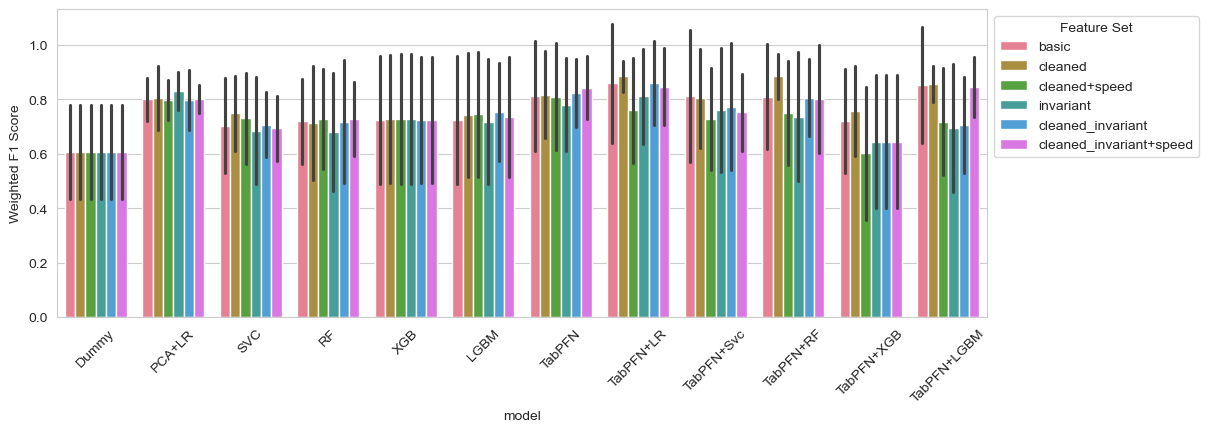

In [ ]:
# Mean F1 Score Comparison by Model and Feature Set
fig, ax = plt.subplots(figsize=(12, 4))

sns.barplot(
    data=all_metrics.filter(pl.col("metric") == "weighted_f1").to_pandas(),
    x="model",
    y="score",
    hue="param_feature_selector__feature_set",
    hue_order=feature_set_order,
    order=MODEL_ORDER,
    ax=ax,
    errorbar=None,
)
ax.set_ylabel("Weighted F1 Score")
ax.legend(title="Feature Set", bbox_to_anchor=(1, 1), loc="upper left")
ax.tick_params(axis="x", rotation=45)

# plt.tight_layout()
plt.show()

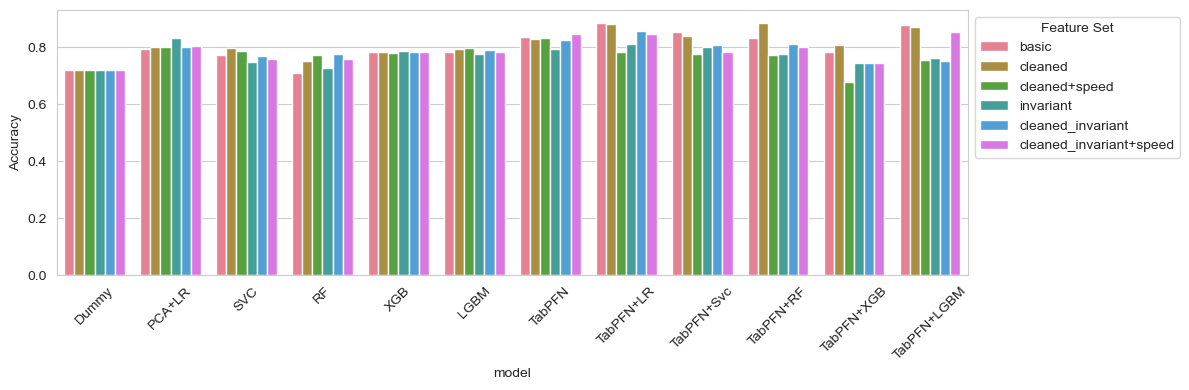

In [78]:
# Mean Accuracy Comparison by Model and Feature Set
fig, ax = plt.subplots(figsize=(12, 4))

sns.barplot(
    data=all_metrics.filter(pl.col("metric") == "accuracy").to_pandas(),
    x="model",
    y="score",
    hue="param_feature_selector__feature_set",
    hue_order=feature_set_order,
    order=MODEL_ORDER,
    ax=ax,
    errorbar=None,
)
ax.set_ylabel("Accuracy")
ax.legend(title="Feature Set", bbox_to_anchor=(1, 1), loc="upper left")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Feature Set Wins

In [53]:
models_name_mapping = {
    "log_reg": "PCA+LR",
    "svc": "SVC",
    "rf": "RF",
    "xgb": "XGB",
    "lgbm": "LGBM",
    "tabpfn": "TabPFN",
    "tabpfn_emb_lgbm": "TabPFN+LGBM",
    "tabpfn_emb_svc": "TabPFN+SVC",
    "tabpfn_emb_xgb": "TabPFN+XGB",
    "tabpfn_emb_log_reg": "TabPFN+PCA+LR",
    "tabpfn_emb_rf": "TabPFN+RF",
}
models = list(models_name_mapping.keys())

res = []
for model in models:
    model_df = pl.read_csv(ROOT_DIR / "results" / f"{model}_logo_{LOGO_GROUP}_results.csv")
    model_df = (
        model_df.group_by(pl.col("^param_.*$").exclude("param_feature_selector__feature_set"))
        .agg([pl.col("param_feature_selector__feature_set"), pl.col("mean_test_weighted_f1")])
        .with_columns(
            # Find the max f1 score in each group
            pl.col("mean_test_weighted_f1").list.max().alias("max_f1")
        )
        .explode(["param_feature_selector__feature_set", "mean_test_weighted_f1"])
        .with_columns(
            # Mark winners (feature sets with the max f1 score)
            (pl.col("mean_test_weighted_f1") == pl.col("max_f1")).alias("is_winner")
        )
        .filter(pl.col("is_winner"))
        .group_by("param_feature_selector__feature_set")
        .agg(pl.len().alias("wins"))
        .with_columns(pl.lit(model).alias("model"))
    )
    res.append(model_df)
final_df = pl.concat(res).with_columns(
    pl.col("model").replace_strict(models_name_mapping).alias("model")
)
final_df

param_feature_selector__feature_set,wins,model
str,u32,str
"""invariant""",38,"""PCA+LR"""
"""basic""",1,"""PCA+LR"""
"""cleaned+speed""",58,"""PCA+LR"""
"""cleaned_invariant+speed""",58,"""PCA+LR"""
"""cleaned""",47,"""PCA+LR"""
…,…,…
"""cleaned_invariant+speed""",2,"""TabPFN+RF"""
"""cleaned_invariant""",2,"""TabPFN+RF"""
"""cleaned+speed""",2,"""TabPFN+RF"""


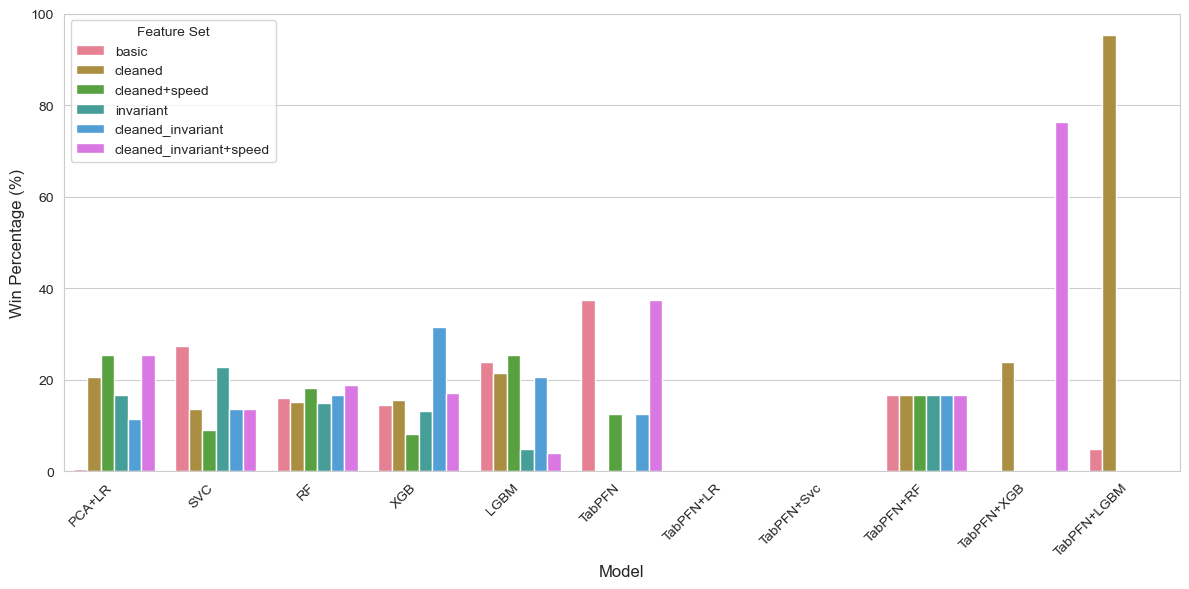

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert to proportions within each model
wins_prop = final_df.with_columns(
    pl.col("wins").sum().over("model").alias("total_wins_per_model")
).with_columns((pl.col("wins") / pl.col("total_wins_per_model") * 100).alias("win_percentage"))

# Convert to pandas only for plotting
plot_df = wins_prop.select(
    ["param_feature_selector__feature_set", "model", "win_percentage"]
).to_pandas()

# Create barplot
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=plot_df,
    x="model",
    y="win_percentage",
    hue="param_feature_selector__feature_set",
    order=MODEL_ORDER[1:],
    hue_order=feature_set_order,
    ax=ax,
)

ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("Win Percentage (%)", fontsize=12)
ax.legend(title="Feature Set")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Splitwise Results

In [55]:
# Plot the different splits

best_models_f1 = (
    df.sort("mean_test_weighted_f1", descending=True)
    .unique(subset=["model"], keep="first")
    .select(
        pl.col("model"),
        pl.col("param_feature_selector__feature_set"),
        pl.col(r"^split\d+_test_weighted_f1$"),
    )
    .unpivot(
        index=["model", "param_feature_selector__feature_set"],
        variable_name="split",
        value_name="score",
    )
    .with_columns(
        pl.lit("weighted_f1").alias("metric"),
    )
)

best_models_acc = (
    df.sort("mean_test_weighted_f1", descending=True)
    .unique(subset=["model"], keep="first")
    .select(
        pl.col("model"),
        pl.col("param_feature_selector__feature_set"),
        pl.col(r"^split\d+_test_acc$"),
    )
    .unpivot(
        index=["model", "param_feature_selector__feature_set"],
        variable_name="split",
        value_name="score",
    )
    .with_columns(
        pl.lit("accuracy").alias("metric"),
    )
)


all_metrics_split = (
    pl.concat([best_models_f1, best_models_acc])
    .with_columns(
        pl.col("split").str.extract(r"(\d+)").cast(pl.Int64).alias("split"),
        pl.col("model").replace_strict(model_name_mapping).alias("model"),
    )
    .with_columns(pl.col("split").replace_strict(idx2name).alias("leave_out_group"))
)

In [56]:
all_metrics_split

model,param_feature_selector__feature_set,split,score,metric,leave_out_group
str,str,i64,f64,str,str
"""TabPFN+Svc""","""basic""",0,0.45,"""weighted_f1""","""ID.4"""
"""Dummy""","""basic""",0,0.45,"""weighted_f1""","""ID.4"""
"""PCA+LR""","""invariant""",0,0.874866,"""weighted_f1""","""ID.4"""
"""LGBM""","""cleaned_invariant""",0,0.534266,"""weighted_f1""","""ID.4"""
"""TabPFN+RF""","""cleaned""",0,0.780952,"""weighted_f1""","""ID.4"""
…,…,…,…,…,…
"""PCA+LR""","""invariant""",3,0.814815,"""accuracy""","""E-Golf"""
"""TabPFN+XGB""","""cleaned""",3,0.740741,"""accuracy""","""E-Golf"""
"""SVC""","""cleaned""",3,0.666667,"""accuracy""","""E-Golf"""


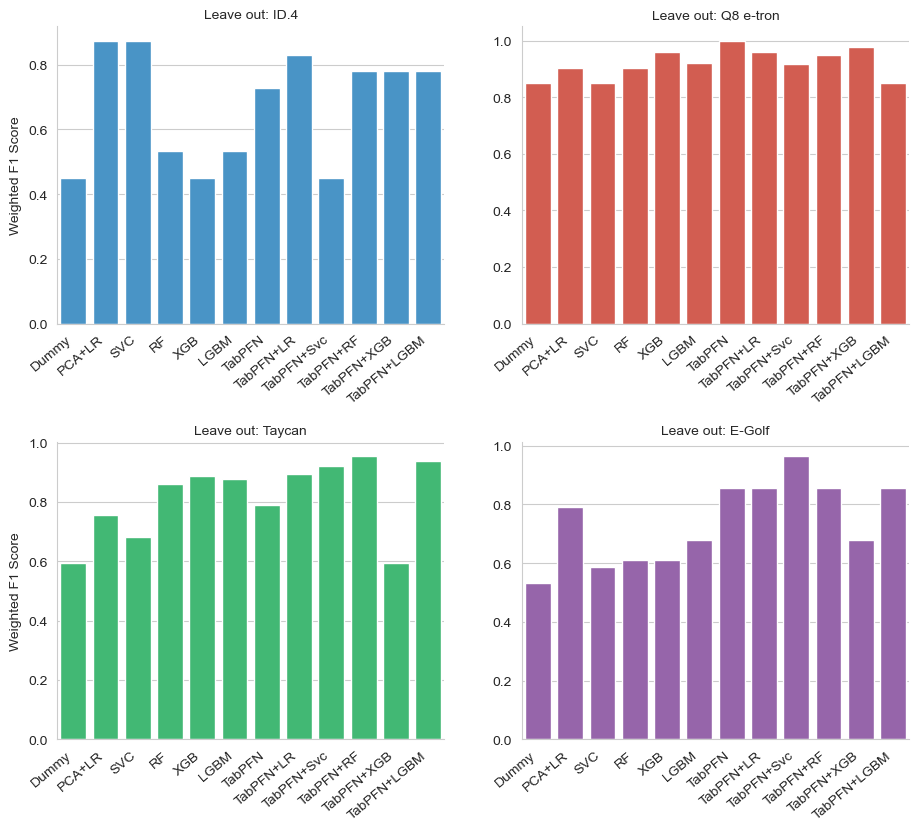

In [57]:
# Weighted F1 Score faceted by Leave-Out Group
plot_data = all_metrics_split.filter(pl.col("metric") == "weighted_f1").to_pandas()

g = sns.catplot(
    data=plot_data,
    x="model",
    y="score",
    col="leave_out_group",
    col_order=SPLIT_ORDER,
    order=MODEL_ORDER,
    kind="bar",
    height=4,
    aspect=1.2,
    hue="leave_out_group",
    palette=SPLIT_PALETTE,
    col_wrap=2,
    legend=False,
    sharex=False,
    sharey=False,
)

g.set_axis_labels("", "Weighted F1 Score")
g.set_titles("Leave out: {col_name}")

for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=40)
    for label in ax.get_xticklabels():
        label.set_ha("right")

g.figure.subplots_adjust(hspace=0.4, wspace=0.2)
plt.show()